# 03 — EWOA Feature Selection + KNN

**Cel**: Reprodukcja artykułu — EWOA selekcja cech → KNN klasyfikacja.

Pipeline:
1. Załaduj dane CIC-MalMem-2022 (55 cech)
2. Uruchom EWOA (20 wielorybów, 30 iteracji)
3. Uruchom WOA (baseline do porównania)
4. Porównaj wyniki z artykułem (accuracy 99.987%, avg 3.97 cech)

In [5]:
import sys, os, time
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
from sklearn.model_selection import train_test_split

from src.data.loader import load_raw_data, preprocess, make_splits
from src.algorithms import EWOA, WOA
from src.evaluation.metrics import evaluate_knn, compare_algorithms
from src.evaluation.visualization import (
    plot_convergence, plot_feature_selection,
    plot_accuracy_comparison, plot_confusion_matrix,
    plot_n_features_comparison,
    )
from src.utils.config import SEED

np.random.seed(SEED)

## 1. Ładowanie i podział danych

Dzielimy dane na trzy części:
- `train` do właściwego uczenia KNN w funkcji fitness,
- `val` do oceny jakości maski cech w EWOA/WOA,
- `test` do końcowej, uczciwej ewaluacji.

In [6]:
df = load_raw_data()
X, y = preprocess(df, mode='multiclass')
X_train_full, X_test, y_train_full, y_test = make_splits(X, y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.125,
    stratify=y_train_full,
    random_state=SEED,
    )

X_fit = np.vstack([X_train, X_val])
y_fit = np.concatenate([y_train, y_val])

feature_names = [c for c in df.columns if c not in ('Category', 'Class')]
print(f'Cechy ({len(feature_names)}): {feature_names[:5]} ...')
print(f'train={X_train.shape}, val={X_val.shape}, test={X_test.shape}')

Wczytano 58058 wierszy z 1 pliku/plików.
Kolumny (57): ['Category', 'pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit'] ...
  58058 próbek | 55 cech | tryb: multiclass
  Rozkład klas: {'Benign': 29227, 'Spyware': 9529, 'Ransomware': 9815, 'Trojan': 9487}
  Split: train=46446, test=11612
Cechy (55): ['pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit', 'pslist.avg_handlers'] ...
train=(40640, 55), val=(5806, 55), test=(11612, 55)


## 2. EWOA — Enhanced Whale Optimization Algorithm

In [7]:
ewoa = EWOA(n_whales=20, max_iter=30, n_neighbors=5, alpha=0.01, seed=SEED)

t0 = time.time()
ewoa_result = ewoa.optimize(X_train, y_train, X_val, y_val)
ewoa_time = time.time() - t0

print(f'\n--- EWOA ---')
print(f'Wybrane cechy ({ewoa_result["n_selected"]}): {ewoa_result["selected_features"]}')
print(f'Fitness: {ewoa_result["best_fitness"]:.6f}')
print(f'Czas: {ewoa_time:.1f} s')

if feature_names:
    selected_names = [feature_names[i] for i in ewoa_result['selected_features']]
    print(f'Nazwy cech: {selected_names}')

  [EWOA] iter   1/30 | fitness=0.226091 | features=28/55 | ~acc=0.7790
  [EWOA] iter   2/30 | fitness=0.219455 | features=30/55 | ~acc=0.7860
  [EWOA] iter   3/30 | fitness=0.219455 | features=30/55 | ~acc=0.7860
  [EWOA] iter   4/30 | fitness=0.219455 | features=30/55 | ~acc=0.7860
  [EWOA] iter   5/30 | fitness=0.219455 | features=30/55 | ~acc=0.7860
  [EWOA] iter   6/30 | fitness=0.219455 | features=30/55 | ~acc=0.7860
  [EWOA] iter   7/30 | fitness=0.219455 | features=30/55 | ~acc=0.7860
  [EWOA] iter   8/30 | fitness=0.219455 | features=30/55 | ~acc=0.7860
  [EWOA] iter   9/30 | fitness=0.219455 | features=30/55 | ~acc=0.7860
  [EWOA] iter  10/30 | fitness=0.219455 | features=30/55 | ~acc=0.7860
  [EWOA] iter  11/30 | fitness=0.219455 | features=30/55 | ~acc=0.7860
  [EWOA] iter  12/30 | fitness=0.219455 | features=30/55 | ~acc=0.7860
  [EWOA] iter  13/30 | fitness=0.219455 | features=30/55 | ~acc=0.7860
  [EWOA] iter  14/30 | fitness=0.219455 | features=30/55 | ~acc=0.7860
  [EWO

## 3. WOA — bazowy Whale Optimization (porównanie)

In [8]:
woa = WOA(n_whales=20, max_iter=30, n_neighbors=5, alpha=0.01, seed=SEED)

t0 = time.time()
woa_result = woa.optimize(X_train, y_train, X_val, y_val)
woa_time = time.time() - t0

print(f'\n--- WOA ---')
print(f'Wybrane cechy ({woa_result["n_selected"]}): {woa_result["selected_features"]}')
print(f'Fitness: {woa_result["best_fitness"]:.6f}')
print(f'Czas: {woa_time:.1f} s')

  [WOA] iter   1/30 | fitness=0.229091 | features= 6/55 | ~acc=0.7720
  [WOA] iter   2/30 | fitness=0.223000 | features=11/55 | ~acc=0.7790
  [WOA] iter   3/30 | fitness=0.223000 | features=11/55 | ~acc=0.7790
  [WOA] iter   4/30 | fitness=0.223000 | features=11/55 | ~acc=0.7790
  [WOA] iter   5/30 | fitness=0.223000 | features=11/55 | ~acc=0.7790
  [WOA] iter   6/30 | fitness=0.222455 | features= 8/55 | ~acc=0.7790
  [WOA] iter   7/30 | fitness=0.222455 | features= 8/55 | ~acc=0.7790
  [WOA] iter   8/30 | fitness=0.222455 | features= 8/55 | ~acc=0.7790
  [WOA] iter   9/30 | fitness=0.203727 | features= 4/55 | ~acc=0.7970
  [WOA] iter  10/30 | fitness=0.203727 | features= 4/55 | ~acc=0.7970
  [WOA] iter  11/30 | fitness=0.203727 | features= 4/55 | ~acc=0.7970
  [WOA] iter  12/30 | fitness=0.203727 | features= 4/55 | ~acc=0.7970
  [WOA] iter  13/30 | fitness=0.203727 | features= 4/55 | ~acc=0.7970
  [WOA] iter  14/30 | fitness=0.203727 | features= 4/55 | ~acc=0.7970
  [WOA] iter  15/30 

## 4. Ewaluacja na zbiorze testowym

In [9]:
print('=== EWOA + KNN ===')
ewoa_eval = evaluate_knn(
    X_fit, y_fit, X_test, y_test,
    selected_features=ewoa_result['selected_features'],
    n_neighbors=5, algorithm_name='EWOA'
    )

print('\n=== WOA + KNN ===')
woa_eval = evaluate_knn(
    X_fit, y_fit, X_test, y_test,
    selected_features=woa_result['selected_features'],
    n_neighbors=5, algorithm_name='WOA'
    )

print('\n=== KNN baseline (55 cech) ===')
baseline_eval = evaluate_knn(
    X_fit, y_fit, X_test, y_test,
    selected_features=list(range(X_fit.shape[1])),
    n_neighbors=5, algorithm_name='KNN-all'
    )

=== EWOA + KNN ===

  EWOA + KNN (k=5)
  Wybrane cechy:  30 / 55
  Accuracy:       0.80270
  F1-macro:       0.70125
  Precision:      0.70356
  Recall:         0.70148

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5846
     Spyware       0.56      0.61      0.59      1906
  Ransomware       0.62      0.66      0.64      1963
      Trojan       0.63      0.54      0.58      1897

    accuracy                           0.80     11612
   macro avg       0.70      0.70      0.70     11612
weighted avg       0.80      0.80      0.80     11612

Zapisano: e:\AGH\Studia magisterskie\8. semestr\Deep Learning and Computational Intelligence\DL-Project\results\metrics\ewoa_results.json

=== WOA + KNN ===

  WOA + KNN (k=5)
  Wybrane cechy:  5 / 55
  Accuracy:       0.82320
  F1-macro:       0.73228
  Precision:      0.73984
  Recall:         0.73265

              precision    recall  f1-score   support

      Benign       1.00      1.00 

## 5. Tabela porównawcza

In [10]:
all_results = [ewoa_eval, woa_eval, baseline_eval]
comparison_df = compare_algorithms(all_results)
comparison_df


=== PORÓWNANIE ALGORYTMÓW ===
Algorytm  Cechy Accuracy F1-macro Precision  Recall
    EWOA     30  0.80270  0.70125   0.70356 0.70148
     WOA      5  0.82320  0.73228   0.73984 0.73265
 KNN-all     55  0.80184  0.70038   0.70181 0.70032

Zapisano: e:\AGH\Studia magisterskie\8. semestr\Deep Learning and Computational Intelligence\DL-Project\results\metrics\comparison.csv


,Algorytm,Cechy,Accuracy,F1-macro,Precision,Recall
0,EWOA,30,0.80270,0.70125,0.70356,0.70148
1,WOA,5,0.82320,0.73228,0.73984,0.73265
2,KNN-all,55,0.80184,0.70038,0.70181,0.70032


## 6. Wizualizacje

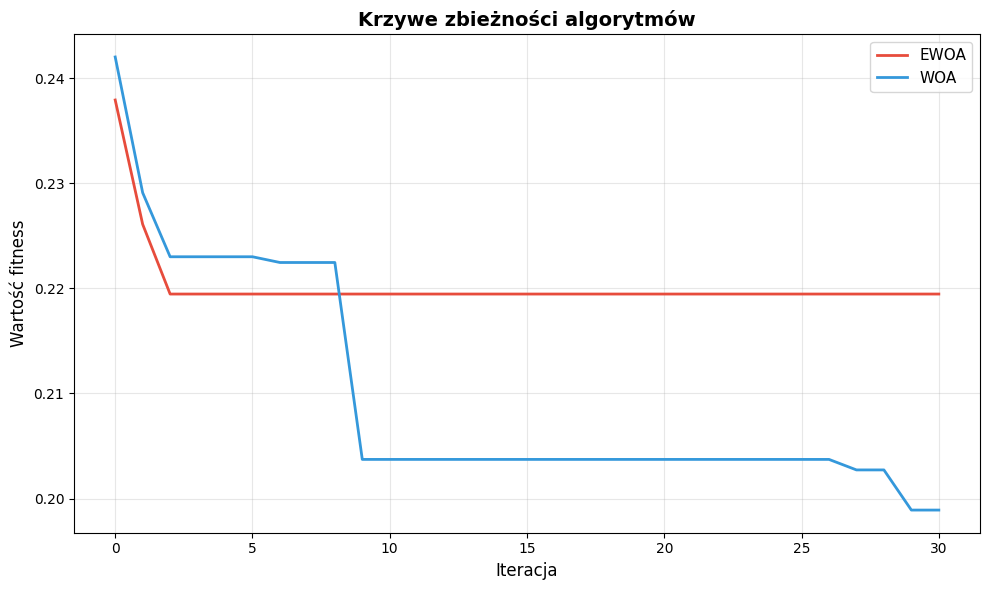

In [12]:
# Krzywe zbieżności
plot_convergence({
    'EWOA': ewoa_result['convergence'],
    'WOA': woa_result['convergence'],
})

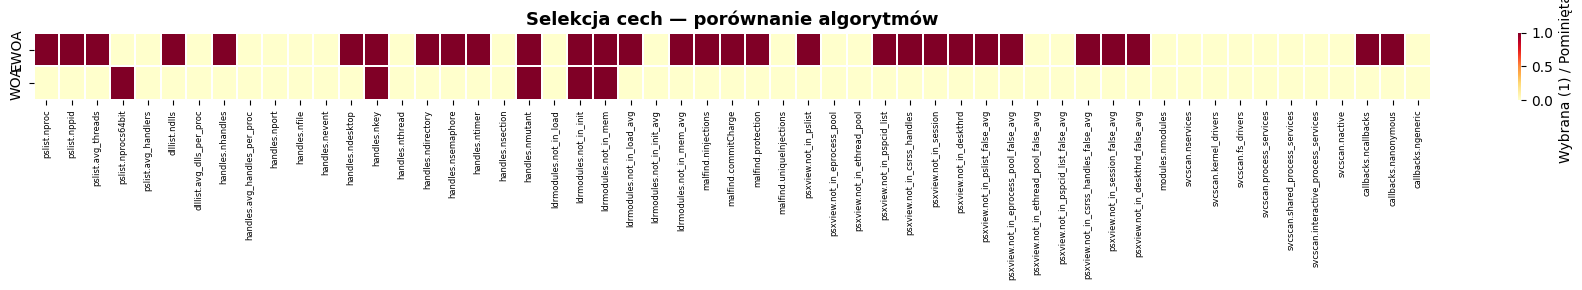

In [13]:
# Heatmapa selekcji cech
plot_feature_selection(
    {'EWOA': ewoa_result['selected_features'], 'WOA': woa_result['selected_features']},
    feature_names=feature_names,
)

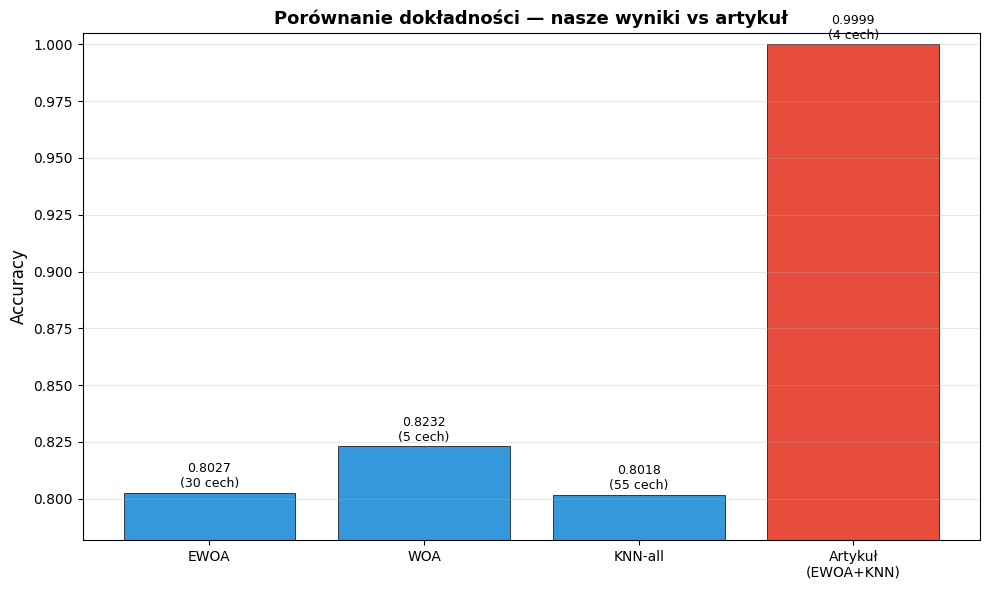

In [14]:
# Porównanie accuracy
plot_accuracy_comparison(all_results)

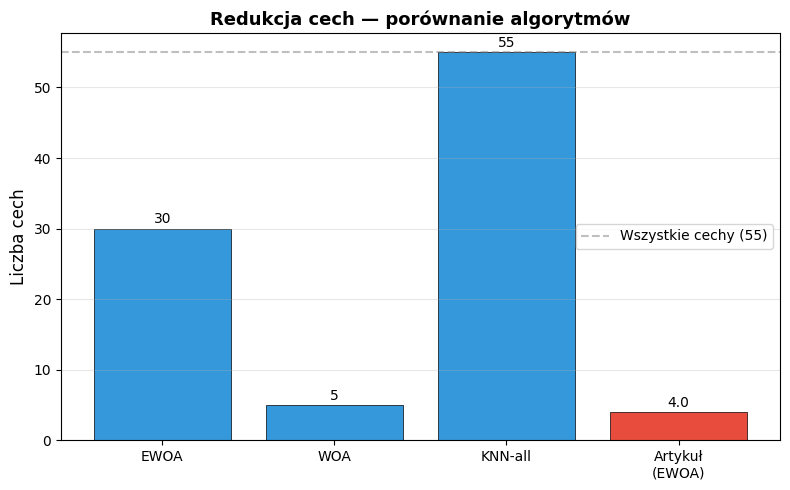

In [15]:
# Porównanie liczby cech
plot_n_features_comparison(all_results)

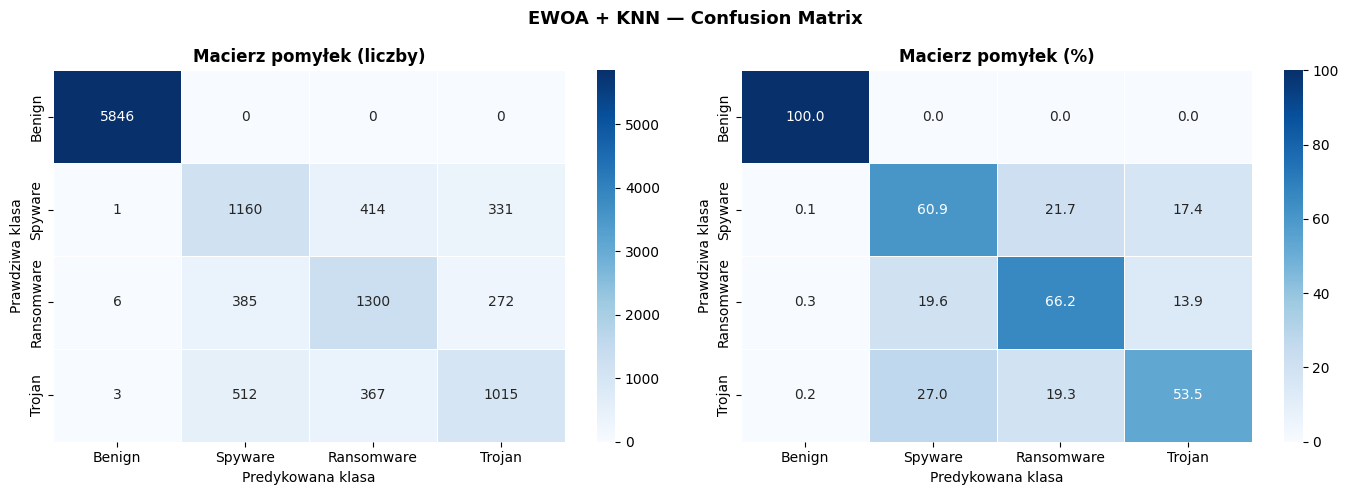

In [16]:
# Confusion matrix — EWOA
from sklearn.neighbors import KNeighborsClassifier

knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_fit[:, ewoa_result['selected_features']], y_fit)
y_pred_ewoa = knn_final.predict(X_test[:, ewoa_result['selected_features']])

plot_confusion_matrix(y_test, y_pred_ewoa, algorithm_name='EWOA', save_name='confusion_ewoa')

## 7. Porównanie z artykułem

| Metryka | Artykuł (EWOA+KNN) | Nasz wynik |
|---------|:---:|:---:|
| Accuracy | 99.987% | **patrz wyżej** |
| Avg. features | 3.97 | **patrz wyżej** |
| Avg. time | 43.19 s | **patrz wyżej** |

In [17]:
print('Porównanie z artykułem:')
print(f'  Accuracy:  nasz={ewoa_eval["accuracy"]:.5f}  vs  artykuł=0.99987')
print(f'  N cech:    nasz={ewoa_eval["n_features"]}      vs  artykuł=3.97 (avg)')
print(f'  Czas:      nasz={ewoa_time:.1f}s    vs  artykuł=43.19s')

Porównanie z artykułem:
  Accuracy:  nasz=0.80270  vs  artykuł=0.99987
  N cech:    nasz=30      vs  artykuł=3.97 (avg)
  Czas:      nasz=65.7s    vs  artykuł=43.19s
